# 07 — Ensemble Model Combinations
**Gurugram Air Quality Study (2020–2024)**

Tests all possible pairwise and group combinations of trained models.
Each combination is evaluated with two strategies: **simple average** and **weighted average** (weights proportional to individual model performance).

**Regression (4 models):** C(4,2)=6 pairs + C(4,3)=4 triples + 1 quad = 11 combinations × 2 strategies  
**Classification (3 models):** C(3,2)=3 pairs + 1 triple = 4 combinations × 2 strategies

**Requires:** Run notebooks 01–04 first (uses identical `random_state=42` split).

In [1]:
import os, time, warnings, itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                              accuracy_score, precision_score, recall_score, f1_score)
import xgboost as xgb
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 150, 'savefig.dpi': 300, 'font.size': 11})

BASE = os.getcwd()
OUT  = os.path.join(BASE, 'outputs')
os.makedirs(OUT, exist_ok=True)

df = pd.read_csv(os.path.join(OUT, 'merged_clean.csv'), parse_dates=['date'])
df = df.sort_values('date').reset_index(drop=True)
print(f'Loaded: {df.shape}')

Loaded: (1768, 32)


## 1. Feature Sets & Train/Test Split
Mirrors notebooks 03 and 04 exactly (same `random_state=42`) so all models share identical test rows.

In [2]:
# ── Regression feature sets (mirrors notebook 03) ───────────────────
REG_TARGET = 'PM2.5 (µg/m³)'

LINEAR_CANDIDATES   = ['RH (%)', 'WS (m/s)', 'month']
BASELINE_CANDIDATES = ['RH (%)', 'WS (m/s)', 'WD (deg)', 'SR (W/mt2)', 'month', 'season_enc']
FULL_CANDIDATES = [
    'RH (%)', 'WS (m/s)', 'WD (deg)', 'SR (W/mt2)', 'BP (mmHg)',
    'LST_C', 'AAI', 'CO', 'HCHO', 'NO2', 'O3',
    'NO2 (µg/m³)', 'CO (mg/m³)', 'Ozone (µg/m³)',
    'month', 'season_enc', 'day_of_year', 'PM2.5_lag1', 'PM2.5_lag7',
]
LINEAR_FEATURES   = [f for f in LINEAR_CANDIDATES   if f in df.columns]
BASELINE_FEATURES = [f for f in BASELINE_CANDIDATES if f in df.columns]
FULL_FEATURES     = [f for f in FULL_CANDIDATES      if f in df.columns]

all_reg_cols = list(set(LINEAR_FEATURES + BASELINE_FEATURES + FULL_FEATURES))
reg_data = df[[REG_TARGET] + all_reg_cols].dropna(subset=[REG_TARGET])

# ── Classification feature set (mirrors notebook 04) ─────────────────
CLF_TARGET = 'AQI_label'
CLF_CANDIDATES = [
    'RH (%)', 'WS (m/s)', 'WD (deg)', 'SR (W/mt2)', 'BP (mmHg)',
    'LST_C', 'AAI', 'CO', 'HCHO', 'NO2', 'O3',
    'NO2 (µg/m³)', 'CO (mg/m³)', 'Ozone (µg/m³)',
    'month', 'season_enc', 'day_of_year',
]
CLF_FEATURES = [f for f in CLF_CANDIDATES if f in df.columns]
clf_data = df[[CLF_TARGET] + CLF_FEATURES].dropna(subset=[CLF_TARGET])

def make_X(X_tr_raw, X_te_raw, feature_list):
    imp = SimpleImputer(strategy='median')
    imp.fit(X_tr_raw)
    Xtr = imp.transform(X_tr_raw)
    Xte = imp.transform(X_te_raw)
    sc  = StandardScaler()
    return sc.fit_transform(Xtr), sc.transform(Xte)

# Regression split
y_reg = reg_data[REG_TARGET].values
idx   = np.arange(len(reg_data))
idx_tr, idx_te = train_test_split(idx, test_size=0.20, random_state=42)
idx_tr, idx_te = sorted(idx_tr), sorted(idx_te)
y_reg_train, y_reg_test = y_reg[idx_tr], y_reg[idx_te]

Xtr_lin,  Xte_lin  = make_X(reg_data[LINEAR_FEATURES].values[idx_tr],
                              reg_data[LINEAR_FEATURES].values[idx_te], LINEAR_FEATURES)
Xtr_base, Xte_base = make_X(reg_data[BASELINE_FEATURES].values[idx_tr],
                              reg_data[BASELINE_FEATURES].values[idx_te], BASELINE_FEATURES)
Xtr_full, Xte_full = make_X(reg_data[FULL_FEATURES].values[idx_tr],
                              reg_data[FULL_FEATURES].values[idx_te], FULL_FEATURES)

# Classification split
clf_imp = SimpleImputer(strategy='median')
clf_imp.fit(clf_data[CLF_FEATURES].values)
X_clf = clf_imp.transform(clf_data[CLF_FEATURES].values)
y_clf = clf_data[CLF_TARGET].values.astype(int)
X_clf_tr, X_clf_te, y_clf_tr, y_clf_te = train_test_split(
    X_clf, y_clf, test_size=0.20, random_state=42, stratify=y_clf)
clf_sc = StandardScaler()
X_clf_tr = clf_sc.fit_transform(X_clf_tr)
X_clf_te = clf_sc.transform(X_clf_te)

print(f'Regression   train/test: {len(y_reg_train)} / {len(y_reg_test)}')
print(f'Classification train/test: {len(y_clf_tr)} / {len(y_clf_te)}')

Regression   train/test: 1414 / 354
Classification train/test: 1414 / 354


## 2. Train All Base Models

In [3]:
# ── Regression models ────────────────────────────────────────────────
lr_m   = LinearRegression().fit(Xtr_lin,  y_reg_train)
rdg_m  = Ridge(alpha=1.0).fit(Xtr_base, y_reg_train)
rf_r   = RandomForestRegressor(n_estimators=200, max_depth=10,
                                random_state=42, n_jobs=-1).fit(Xtr_full, y_reg_train)
xgb_r  = xgb.XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6,
                            subsample=0.8, colsample_bytree=0.8,
                            random_state=42, verbosity=0).fit(Xtr_full, y_reg_train)

reg_preds = {
    'Linear':  lr_m.predict(Xte_lin),
    'Ridge':   rdg_m.predict(Xte_base),
    'RF':      rf_r.predict(Xte_full),
    'XGBoost': xgb_r.predict(Xte_full),
}
reg_r2_ind = {m: r2_score(y_reg_test, p) for m, p in reg_preds.items()}
print('Individual regression R2:')
for m, r in reg_r2_ind.items():
    print(f'  {m}: {r:.3f}')

# ── Classification models ────────────────────────────────────────────
log_c  = LogisticRegression(max_iter=1000, random_state=42).fit(X_clf_tr, y_clf_tr)
rf_c   = RandomForestClassifier(n_estimators=200, random_state=42,
                                  n_jobs=-1).fit(X_clf_tr, y_clf_tr)
xgb_c  = xgb.XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=6,
                             random_state=42, verbosity=0,
                             eval_metric='mlogloss').fit(X_clf_tr, y_clf_tr)

clf_probas = {
    'Logistic': log_c.predict_proba(X_clf_te),
    'RF':       rf_c.predict_proba(X_clf_te),
    'XGBoost':  xgb_c.predict_proba(X_clf_te),
}
clf_acc_ind = {m: accuracy_score(y_clf_te, p.argmax(axis=1))
               for m, p in clf_probas.items()}
print('Individual classification accuracy:')
for m, a in clf_acc_ind.items():
    print(f'  {m}: {a:.3f}')

Individual regression R2:
  Linear: 0.019
  Ridge: 0.199
  RF: 0.589
  XGBoost: 0.634
Individual classification accuracy:
  Logistic: 0.480
  RF: 0.627
  XGBoost: 0.616


## 3. Regression Ensembles

All C(4,2)=6 pairs, C(4,3)=4 triples, C(4,4)=1 quad evaluated with:
- **[avg]** Simple average of predictions
- **[wtd]** Weighted average — weights = `max(0, R²_i)` normalised to sum=1 (near-zero R² models get near-zero weight automatically)

In [4]:
def eval_reg(name, y_true, y_pred):
    return {
        'Model': name,
        'MAE':  round(mean_absolute_error(y_true, y_pred), 2),
        'RMSE': round(float(np.sqrt(mean_squared_error(y_true, y_pred))), 2),
        'R2':   round(r2_score(y_true, y_pred), 3),
    }

reg_rows = [eval_reg(f'{m} (individual)', y_reg_test, reg_preds[m])
            for m in ['Linear', 'Ridge', 'RF', 'XGBoost']]

for size in range(2, len(reg_preds) + 1):
    for combo in itertools.combinations(reg_preds.keys(), size):
        label = ' + '.join(combo)
        preds = np.array([reg_preds[m] for m in combo])

        # Simple average
        reg_rows.append(eval_reg(f'{label} [avg]', y_reg_test, preds.mean(axis=0)))

        # Weighted average by R2
        w = np.array([max(0.0, reg_r2_ind[m]) for m in combo], dtype=float)
        w = w / w.sum() if w.sum() > 0 else np.ones(len(combo)) / len(combo)
        wtd = (preds * w[:, None]).sum(axis=0)
        reg_rows.append(eval_reg(f'{label} [wtd]', y_reg_test, wtd))

reg_ens_df = (pd.DataFrame(reg_rows)
              .sort_values('R2', ascending=False)
              .reset_index(drop=True))
reg_ens_df.to_csv(os.path.join(OUT, 'ensemble_regression_comparison.csv'), index=False)

print('REGRESSION ENSEMBLE RESULTS (sorted by R2)')
print('=' * 65)
print(reg_ens_df.to_string(index=False))
print('=' * 65)

REGRESSION ENSEMBLE RESULTS (sorted by R2)
                              Model   MAE  RMSE    R2
               XGBoost (individual) 23.47 35.88 0.634
             Linear + XGBoost [wtd] 23.60 36.05 0.630
                 RF + XGBoost [wtd] 23.06 36.39 0.623
                 RF + XGBoost [avg] 23.06 36.43 0.622
        Linear + RF + XGBoost [wtd] 23.15 36.50 0.621
         Ridge + RF + XGBoost [wtd] 24.15 37.52 0.600
Linear + Ridge + RF + XGBoost [wtd] 24.30 37.65 0.597
              Ridge + XGBoost [wtd] 25.20 37.88 0.592
                    RF (individual) 23.84 38.03 0.589
     Linear + Ridge + XGBoost [wtd] 25.43 38.12 0.587
                  Linear + RF [wtd] 24.07 38.25 0.584
         Ridge + RF + XGBoost [avg] 26.77 39.90 0.547
                   Ridge + RF [wtd] 26.32 40.13 0.542
          Linear + Ridge + RF [wtd] 26.59 40.37 0.536
        Linear + RF + XGBoost [avg] 28.04 40.90 0.524
              Ridge + XGBoost [avg] 29.00 41.86 0.501
Linear + Ridge + RF + XGBoost [avg] 30.

## 4. Regression Comparison Chart

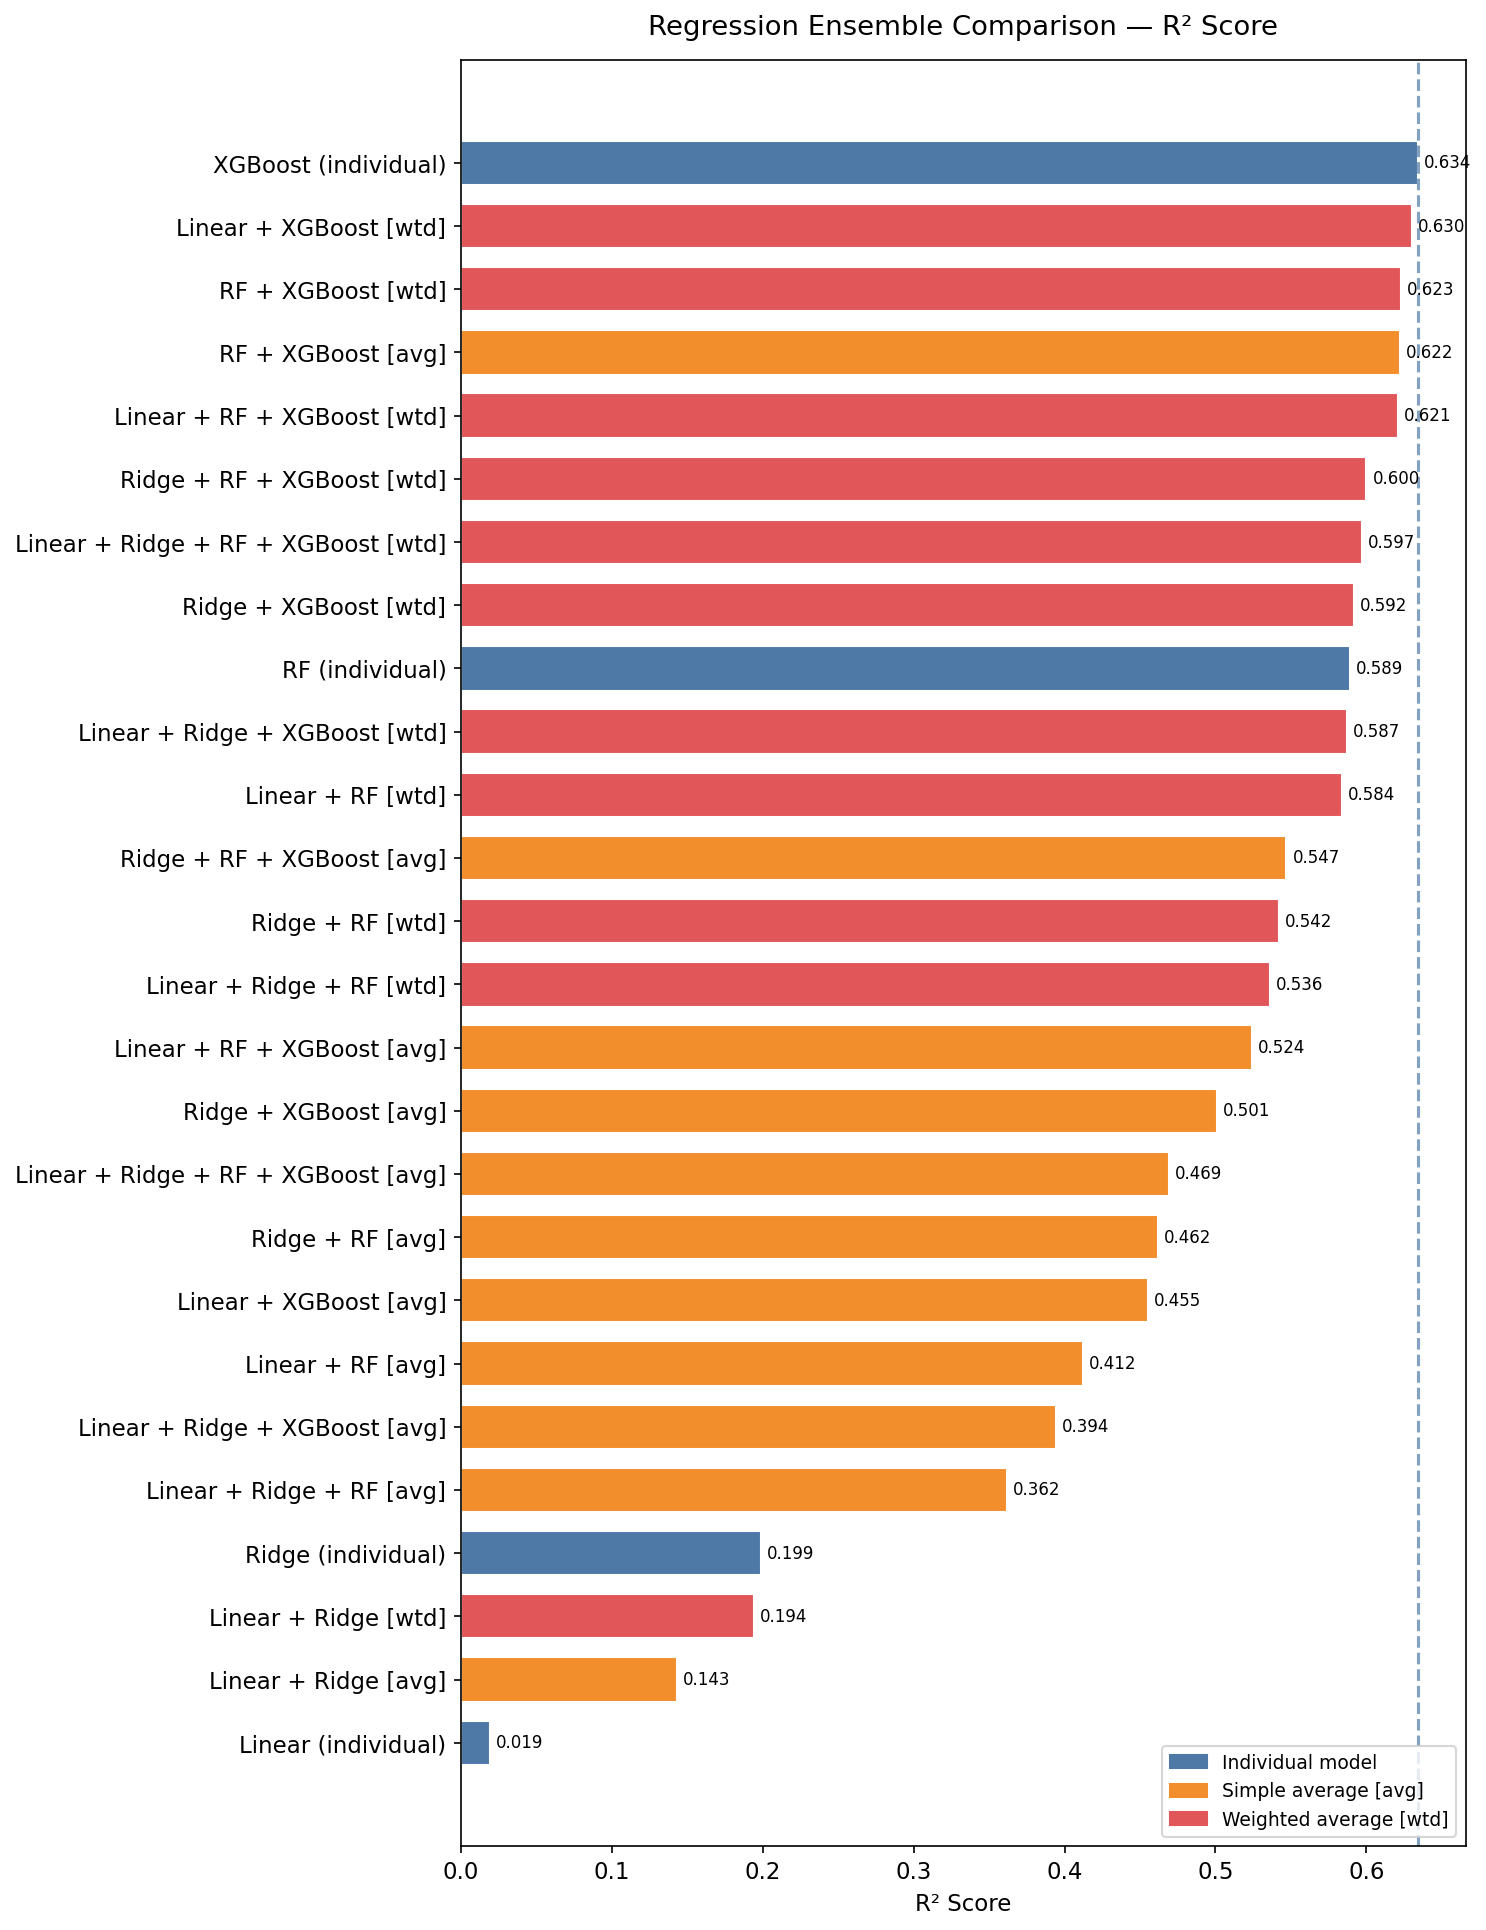

In [5]:
fig, ax = plt.subplots(figsize=(10, 13))

palette = {'individual': '#4e79a7', 'avg': '#f28e2b', 'wtd': '#e15759'}
bar_colors = []
for name in reg_ens_df['Model']:
    if 'individual' in name:  bar_colors.append(palette['individual'])
    elif '[wtd]' in name:     bar_colors.append(palette['wtd'])
    else:                     bar_colors.append(palette['avg'])

bars = ax.barh(reg_ens_df['Model'], reg_ens_df['R2'],
               color=bar_colors, edgecolor='white', height=0.7)
best_ind = reg_ens_df[reg_ens_df['Model'].str.contains('individual')]['R2'].max()
ax.axvline(best_ind, color='#4e79a7', ls='--', lw=1.5, alpha=0.7,
           label=f'Best individual R² = {best_ind:.3f}')

ax.set_xlabel('R² Score')
ax.set_title('Regression Ensemble Comparison — R² Score', pad=12)
ax.invert_yaxis()
ax.legend(handles=[
    mpatches.Patch(color=palette['individual'], label='Individual model'),
    mpatches.Patch(color=palette['avg'],        label='Simple average [avg]'),
    mpatches.Patch(color=palette['wtd'],        label='Weighted average [wtd]'),
], fontsize=9, loc='lower right')

for bar, val in zip(bars, reg_ens_df['R2']):
    ax.text(max(val, 0) + 0.004, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=8)

plt.tight_layout()
fig.savefig(os.path.join(OUT, 'ensemble_regression_r2_chart.png'), bbox_inches='tight')
plt.show()

## 5. Classification Ensembles

All C(3,2)=3 pairs and C(3,3)=1 triple evaluated with:
- **[soft]** Soft voting — simple average of predicted class probabilities
- **[wtd]** Weighted soft voting — weights by individual accuracy

In [6]:
def eval_clf(name, y_true, y_pred):
    return {
        'Model':         name,
        'Accuracy':      round(accuracy_score(y_true, y_pred), 3),
        'Precision (W)': round(precision_score(y_true, y_pred, average='weighted', zero_division=0), 3),
        'Recall (W)':    round(recall_score(y_true, y_pred, average='weighted', zero_division=0), 3),
        'F1-Score (W)':  round(f1_score(y_true, y_pred, average='weighted', zero_division=0), 3),
    }

clf_rows = [eval_clf(f'{m} (individual)', y_clf_te, clf_probas[m].argmax(axis=1))
            for m in ['Logistic', 'RF', 'XGBoost']]

for size in range(2, len(clf_probas) + 1):
    for combo in itertools.combinations(clf_probas.keys(), size):
        label = ' + '.join(combo)
        probas = np.array([clf_probas[m] for m in combo])

        # Soft voting (simple average of probabilities)
        avg_p = probas.mean(axis=0)
        clf_rows.append(eval_clf(f'{label} [soft]', y_clf_te, avg_p.argmax(axis=1)))

        # Weighted soft voting (by accuracy)
        w = np.array([clf_acc_ind[m] for m in combo], dtype=float)
        w = w / w.sum()
        wtd_p = (probas * w[:, None, None]).sum(axis=0)
        clf_rows.append(eval_clf(f'{label} [wtd]', y_clf_te, wtd_p.argmax(axis=1)))

clf_ens_df = (pd.DataFrame(clf_rows)
              .sort_values('Accuracy', ascending=False)
              .reset_index(drop=True))
clf_ens_df.to_csv(os.path.join(OUT, 'ensemble_classification_comparison.csv'), index=False)

print('CLASSIFICATION ENSEMBLE RESULTS (sorted by Accuracy)')
print('=' * 72)
print(clf_ens_df.to_string(index=False))
print('=' * 72)

CLASSIFICATION ENSEMBLE RESULTS (sorted by Accuracy)
                         Model  Accuracy  Precision (W)  Recall (W)  F1-Score (W)
               RF (individual)     0.627          0.603       0.627         0.593
          XGBoost (individual)     0.616          0.597       0.616         0.596
           RF + XGBoost [soft]     0.616          0.593       0.616         0.592
            RF + XGBoost [wtd]     0.616          0.593       0.616         0.592
Logistic + RF + XGBoost [soft]     0.610          0.590       0.610         0.579
 Logistic + RF + XGBoost [wtd]     0.610          0.583       0.610         0.580
      Logistic + XGBoost [wtd]     0.605          0.578       0.605         0.574
           Logistic + RF [wtd]     0.602          0.550       0.602         0.558
     Logistic + XGBoost [soft]     0.602          0.574       0.602         0.570
          Logistic + RF [soft]     0.590          0.540       0.590         0.547
         Logistic (individual)     0.480     

## 6. Classification Comparison Chart

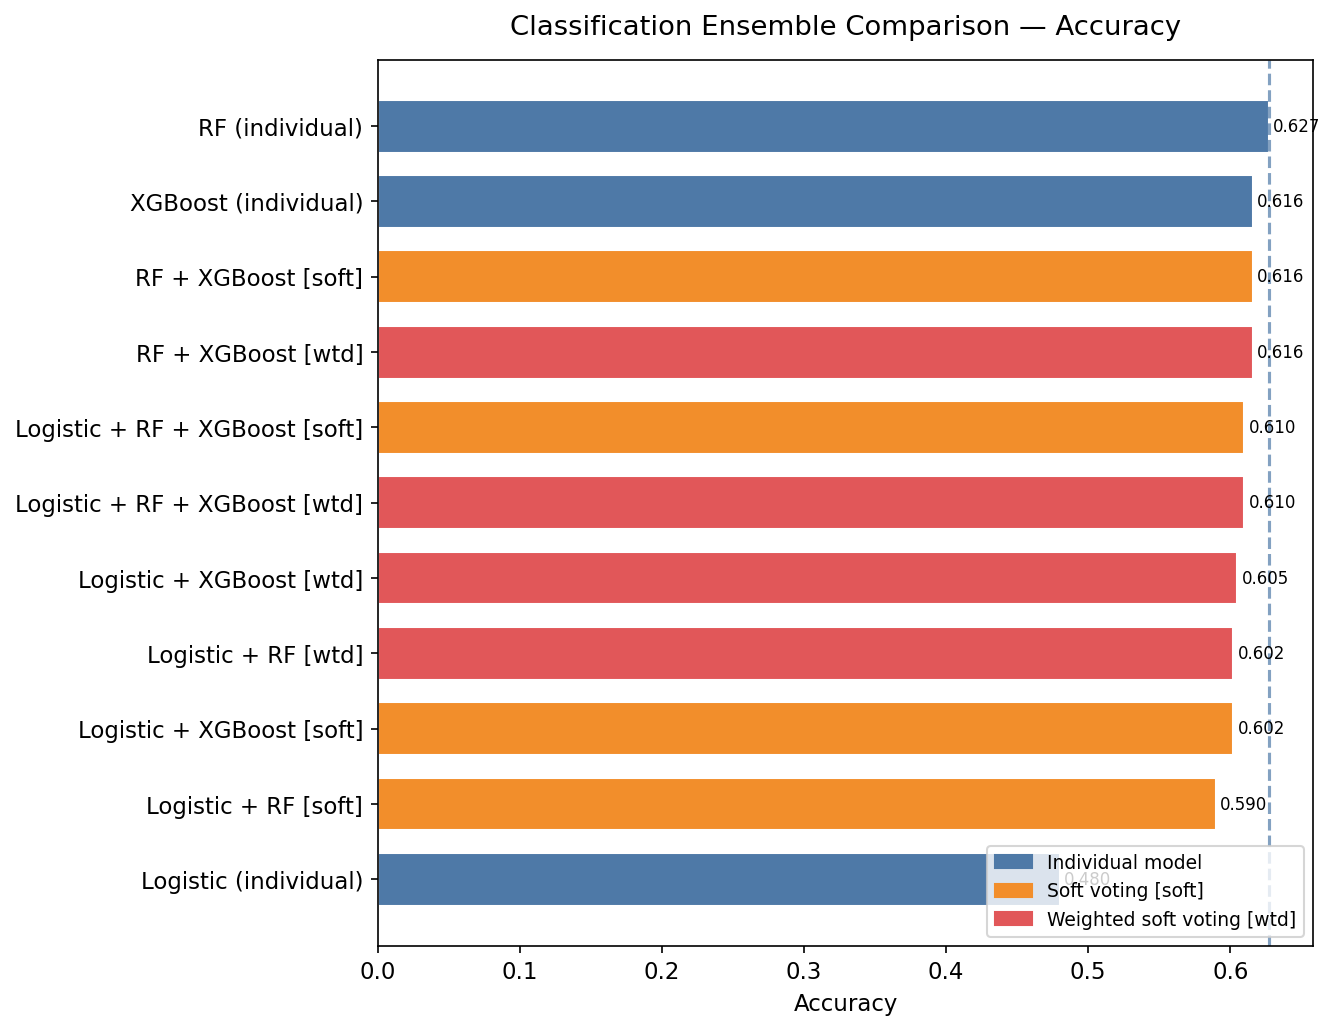

In [7]:
fig, ax = plt.subplots(figsize=(9, 7))

bar_colors_clf = []
for name in clf_ens_df['Model']:
    if 'individual' in name:  bar_colors_clf.append(palette['individual'])
    elif '[wtd]' in name:     bar_colors_clf.append(palette['wtd'])
    else:                     bar_colors_clf.append(palette['avg'])

bars = ax.barh(clf_ens_df['Model'], clf_ens_df['Accuracy'],
               color=bar_colors_clf, edgecolor='white', height=0.7)
best_ind_clf = clf_ens_df[clf_ens_df['Model'].str.contains('individual')]['Accuracy'].max()
ax.axvline(best_ind_clf, color='#4e79a7', ls='--', lw=1.5, alpha=0.7,
           label=f'Best individual Accuracy = {best_ind_clf:.3f}')

ax.set_xlabel('Accuracy')
ax.set_title('Classification Ensemble Comparison — Accuracy', pad=12)
ax.invert_yaxis()
ax.legend(handles=[
    mpatches.Patch(color=palette['individual'], label='Individual model'),
    mpatches.Patch(color=palette['avg'],        label='Soft voting [soft]'),
    mpatches.Patch(color=palette['wtd'],        label='Weighted soft voting [wtd]'),
], fontsize=9, loc='lower right')

for bar, val in zip(bars, clf_ens_df['Accuracy']):
    ax.text(val + 0.003, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=8)

plt.tight_layout()
fig.savefig(os.path.join(OUT, 'ensemble_classification_accuracy_chart.png'), bbox_inches='tight')
plt.show()

## 7. Summary

In [8]:
best_reg_ens = reg_ens_df[~reg_ens_df['Model'].str.contains('individual')].iloc[0]
best_reg_ind = reg_ens_df[reg_ens_df['Model'].str.contains('individual')].iloc[0]
best_clf_ens = clf_ens_df[~clf_ens_df['Model'].str.contains('individual')].iloc[0]
best_clf_ind = clf_ens_df[clf_ens_df['Model'].str.contains('individual')].iloc[0]

print('=' * 65)
print('ENSEMBLE SUMMARY')
print('=' * 65)
print('REGRESSION')
print(f'  Best individual : {best_reg_ind["Model"]}')
print(f'                    R2 = {best_reg_ind["R2"]:.3f}')
print(f'  Best ensemble   : {best_reg_ens["Model"]}')
print(f'                    R2 = {best_reg_ens["R2"]:.3f}')
delta_r = best_reg_ens['R2'] - best_reg_ind['R2']
print(f'  Delta R2 = {delta_r:+.3f}  ({"ensemble wins" if delta_r > 0 else "individual holds"})')
print('CLASSIFICATION')
print(f'  Best individual : {best_clf_ind["Model"]}')
print(f'                    Accuracy = {best_clf_ind["Accuracy"]:.3f}')
print(f'  Best ensemble   : {best_clf_ens["Model"]}')
print(f'                    Accuracy = {best_clf_ens["Accuracy"]:.3f}')
delta_c = best_clf_ens['Accuracy'] - best_clf_ind['Accuracy']
print(f'  Delta Accuracy = {delta_c:+.3f}  ({"ensemble wins" if delta_c > 0 else "individual holds"})')
print('=' * 65)

ENSEMBLE SUMMARY
REGRESSION
  Best individual : XGBoost (individual)
                    R2 = 0.634
  Best ensemble   : Linear + XGBoost [wtd]
                    R2 = 0.630
  Delta R2 = -0.004  (individual holds)
CLASSIFICATION
  Best individual : RF (individual)
                    Accuracy = 0.627
  Best ensemble   : RF + XGBoost [soft]
                    Accuracy = 0.616
  Delta Accuracy = -0.011  (individual holds)
